In [1]:
import SRC
import os
import sys
from SRC.helpFolder import *

metadata = SRC.load_model_metadata()

In [2]:
metadata['weatherInformation']['weather_end_date'], metadata['PMSInformation']['end_date_range']

('2025-06-07', '2025-08-30')

### prepare the **data**

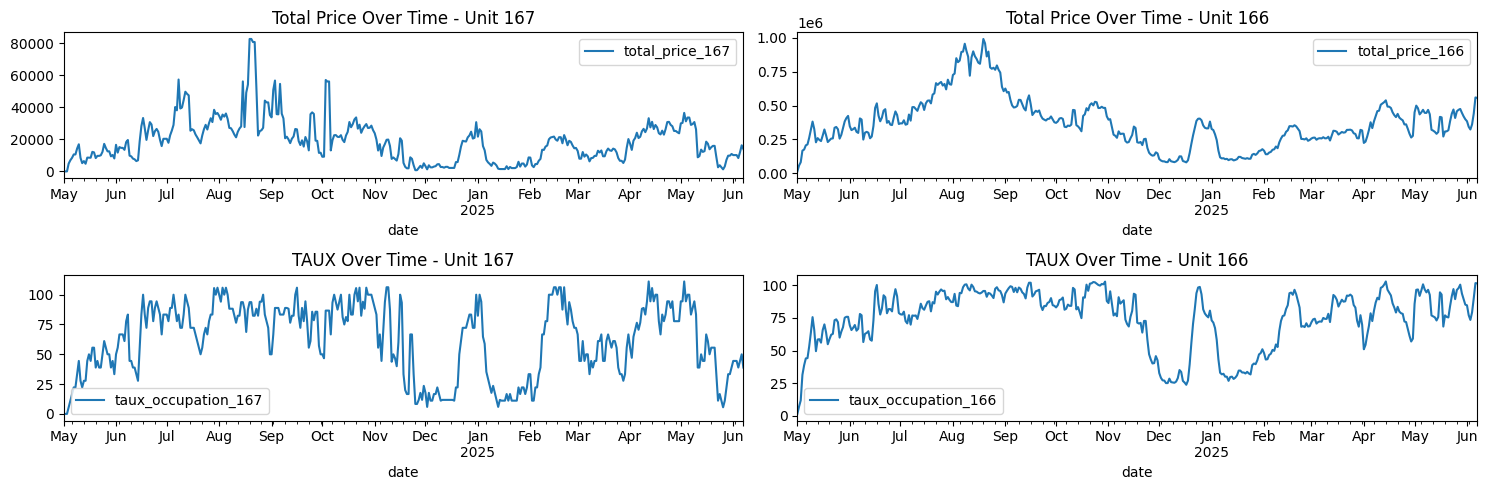

In [3]:
df_167, df_166 = prepare_and_plot_data(
    csv_path = metadata['PMSInformation']['final_csv_path'],
    start_date = metadata['PMSInformation']['start_date_range'],
    end_date = metadata['weatherInformation']['weather_end_date']
)

In [4]:
df_weather = make_weather_data_dataframe(weather_data_path = f"../{metadata['weatherInformation']['archive_json_path']}")

In [5]:
df_weather.head()

,temperature_max,temperature_min,temperature_mean,precipitation,windspeed_max,temperature_range
date,,,,,,
2024-05-01,26.326,10.676,17.949,0.0,13.556,15.65
2024-05-02,27.276,11.126,19.288,0.0,13.398,16.15
2024-05-03,31.876,10.726,21.576,0.0,11.542,21.15
2024-05-04,33.676,17.126,24.372,0.0,17.699,16.55
2024-05-05,33.476,14.076,23.649,0.0,20.189,19.40


In [6]:
df_166.head()

,dayofweek,month,year,dayofyear,weekofyear,total_price_166,taux_occupation_166
date,,,,,,,
2024-05-01,2,5,2024,122,18,14048.16,1.45
2024-05-02,3,5,2024,123,18,57342.62,7.00
2024-05-03,4,5,2024,124,18,81992.10,11.84
2024-05-04,5,5,2024,125,18,167465.61,31.40
2024-05-05,6,5,2024,126,18,175461.31,38.65


In [7]:
df_167.head()

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167
date,,,,,,,
2024-05-01,2,5,2024,122,18,0.0,0.00
2024-05-02,3,5,2024,123,18,0.0,0.00
2024-05-03,4,5,2024,124,18,0.0,0.00
2024-05-04,5,5,2024,125,18,4850.0,5.56
2024-05-05,6,5,2024,126,18,6950.0,11.11


In [8]:
df_weather.columns, df_166.columns, df_167.columns

(Index(['temperature_max', 'temperature_min', 'temperature_mean',
        'precipitation', 'windspeed_max', 'temperature_range'],
       dtype='object'),
 Index(['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
        'total_price_166', 'taux_occupation_166'],
       dtype='object'),
 Index(['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
        'total_price_167', 'taux_occupation_167'],
       dtype='object'))

In [9]:
df_166_weather = pd.concat([df_166, df_weather], axis=1)
df_167_weather = pd.concat([df_167, df_weather], axis=1)

In [10]:
df_167_weather.head()

,dayofweek,month,year,dayofyear,weekofyear,total_price_167,taux_occupation_167,temperature_max,temperature_min,temperature_mean,precipitation,windspeed_max,temperature_range
date,,,,,,,,,,,,,
2024-05-01,2,5,2024,122,18,0.0,0.00,26.326,10.676,17.949,0.0,13.556,15.65
2024-05-02,3,5,2024,123,18,0.0,0.00,27.276,11.126,19.288,0.0,13.398,16.15
2024-05-03,4,5,2024,124,18,0.0,0.00,31.876,10.726,21.576,0.0,11.542,21.15
2024-05-04,5,5,2024,125,18,4850.0,5.56,33.676,17.126,24.372,0.0,17.699,16.55
2024-05-05,6,5,2024,126,18,6950.0,11.11,33.476,14.076,23.649,0.0,20.189,19.40


In [11]:
df_167_weather.columns

Index(['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
       'total_price_167', 'taux_occupation_167', 'temperature_max',
       'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max',
       'temperature_range'],
      dtype='object')

In [12]:
df_166_weather.columns

Index(['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
       'total_price_166', 'taux_occupation_166', 'temperature_max',
       'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max',
       'temperature_range'],
      dtype='object')

In [13]:
df_166_weather.isna().sum()

dayofweek              0
month                  0
year                   0
dayofyear              0
weekofyear             0
total_price_166        0
taux_occupation_166    0
temperature_max        0
temperature_min        0
temperature_mean       0
precipitation          0
windspeed_max          0
temperature_range      0
dtype: int64

In [14]:
df_166_weather.fillna(0, inplace=True)

In [15]:
def split_data_train_test(df, unit_id, test_size=0.2, target_type='price', feature_columns=None):
    """
    Splits the DataFrame chronologically into training and testing sets.
    
    Args:
        df: DataFrame containing the data
        unit_id: Unit identifier (e.g., '166', '167')
        test_size: Proportion of data to use for testing
        target_type: Type of target ('price' or 'taux')
        feature_columns: List of column names to use as features. If None, uses all columns except target and date.
    """
    df_copy = df.copy()

    if df_copy.index.name == 'date':
        df_copy = df_copy.sort_index()
    elif 'date' in df_copy.columns:
        df_copy = df_copy.sort_values('date').reset_index(drop=True)
    else:
        print("Warning: No 'date' index or column found. Assuming index is chronological.")
        df_copy = df_copy.sort_index()
        if df_copy.index.name == 'date':
             df_copy = df_copy.reset_index()

    price_col = f'total_price_{unit_id}'
    taux_col = f'taux_occupation_{unit_id}'
    
    if target_type.lower() == 'price':
        target_col = price_col
        default_feature_col = taux_col
    else:  
        target_col = taux_col
        default_feature_col = price_col
        
    if target_col not in df_copy.columns:
        raise ValueError(f"Target column '{target_col}' not found in DataFrame.")
    
    if feature_columns is None:
        X = df_copy.drop([target_col], axis=1, errors='ignore')
        if 'date' in X.columns:
            X = X.drop('date', axis=1, errors='ignore')
        print(f"Using all available features: {X.columns.tolist()}")
    else:
        missing_features = [col for col in feature_columns if col not in df_copy.columns]
        if missing_features:
            raise ValueError(f"Feature columns not found in DataFrame: {missing_features}")
        
        X = df_copy[feature_columns].copy()
        print(f"Using specified features: {feature_columns}")
    
    y = df_copy[target_col]

    split_idx = int(len(df_copy) * (1 - test_size))
    if split_idx == 0 or split_idx >= len(df_copy):
        raise ValueError("test_size results in an invalid split index.")

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    print(f"Split complete. Test size: {test_size:.2f}")
    print(f"Target column: {target_col}")
    print(f"Features used: {X_train.columns.tolist()}")
    print(f"Training set range: {X_train.index.min()} to {X_train.index.max()} ({len(X_train)} samples)")
    print(f"Testing set range: {X_test.index.min()} to {X_test.index.max()} ({len(X_test)} samples)")

    return X_train, X_test, y_train, y_test, target_col, feature_columns or X_train.columns.tolist()


def run_linear_regression_pipeline(df_unit, unit_id, test_size=0.2, target_type='price', feature_columns=None):
    """
    Runs the complete Linear Regression training, evaluation, and plotting pipeline
    for a specific unit with flexible feature selection.

    Args:
        df_unit (pd.DataFrame): The DataFrame containing data for the specific unit.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        test_size (float): The proportion of the data to use for the test set.
        target_type (str): Type of target ('price' or 'taux')
        feature_columns (list): List of column names to use as features. If None, uses all available features.
                               Example: ['taux_occupation_166', 'dayofweek', 'month', 'temperature']
    """
    print(f"--- Starting Linear Regression Pipeline for Unit {unit_id} ---")
    print(f"Target type: {target_type} (predicting {'price' if target_type=='price' else 'occupancy rate'})")
    
    if feature_columns:
        print(f"Custom features specified: {feature_columns}")
    else:
        print("Using all available features (excluding target and date)")

    print(f"\n[Step 1/3] Splitting data with test_size={test_size}...")
    try:
        X_train, X_test, y_train, y_test, target_col, used_features = split_data_train_test(
            df_unit, unit_id, test_size=test_size, target_type=target_type, feature_columns=feature_columns
        )
    
    except ValueError as e:
        print(f"Error during data splitting: {e}")
        return None
    
    except Exception as e:
         print(f"An unexpected error occurred during data splitting: {e}")
         traceback.print_exc()
         return None

    print("\n[Step 2/3] Training and evaluating Linear Regression model...")
    
    try:
        model_results = train_evaluate_linear_model(
            X_train, X_test, y_train, y_test, target_col
        )

        model_results['target_col'] = target_col
        model_results['used_features'] = used_features
        model_results['target_type'] = 'price' if 'price' in target_col else 'taux'
        
    except Exception as e:
         print(f"An unexpected error occurred during training/evaluation: {e}")
         traceback.print_exc()
         return None

    print("\n[Step 3/3] Plotting results...")

    try:
        print("Plotting predictions on train/test split...")
        plot_predictions_over_time(model_results, df_unit, unit_id, 
                                 target_type=model_results['target_type'])

        print("Plotting predictions on the full unit DataFrame...")
        plot_actual_vs_predicted(model_results['model'], df_unit, unit_id, 
                               target_type=model_results['target_type'])

    except KeyError as e:
        print(f"Error during plotting: Missing key in model_results - {e}")
        traceback.print_exc()

    except Exception as e:
        print(f"An unexpected error occurred during plotting: {e}")
        traceback.print_exc()

    print(f"\nPipeline finished for Unit {unit_id}.")
    print("--- End Linear Regression Pipeline ---")

    return model_results


def plot_actual_vs_predicted(model, df, unit_id, target_type=None, feature_columns=None):
    """
    Plots the actual vs. predicted values for the entire dataset using a trained model.
    Can handle both price and occupancy rate (taux) predictions with flexible features.
    """
    df_copy = df.copy()

    if df_copy.index.name == 'date':
        df_copy = df_copy.sort_index()
    elif 'date' in df_copy.columns:
        df_copy = df_copy.sort_values('date') 
    else:
        print("Warning: DataFrame must have a 'date' index or column for plotting.")
        df_copy = df_copy.sort_index()

    price_col = f'total_price_{unit_id}'
    taux_col = f'taux_occupation_{unit_id}'
    
    if target_type == 'price':
        target_col = price_col
        y_label = 'Price'
        title_prefix = 'Prices'
    elif target_type == 'taux':
        target_col = taux_col
        y_label = 'Occupancy Rate'
        title_prefix = 'Occupancy Rates'
    else:
        if hasattr(model, 'feature_names_in_'):
            model_features = list(model.feature_names_in_)
            if price_col in model_features and taux_col not in model_features:
                target_col = taux_col
                y_label = 'Occupancy Rate'
                title_prefix = 'Occupancy Rates'
            else:
                target_col = price_col
                y_label = 'Price'
                title_prefix = 'Prices'
        else:
            target_col = price_col
            y_label = 'Price'
            title_prefix = 'Prices'
    
    if target_col not in df_copy.columns:
        print(f"Error: Target column '{target_col}' not found in DataFrame.")
        return

    if hasattr(model, 'feature_names_in_'):
        expected_features = list(model.feature_names_in_)
        print(f"Model expects features: {expected_features}")
        
        missing_features = [f for f in expected_features if f not in df_copy.columns]
        if missing_features:
            print(f"Error: Missing features for prediction: {missing_features}")
            return
            
        features = df_copy[expected_features]
    else:
        features = df_copy.drop([target_col], axis=1, errors='ignore')
        if 'date' in features.columns:
            features = features.drop('date', axis=1, errors='ignore')

    print(f"Columns used for prediction: {features.columns.tolist()}")
    print(f"Target column: {target_col}")

    try:
        predictions = model.predict(features)
    except Exception as e:
        print(f"Error during prediction: {e}")
        print(f"Feature shape: {features.shape}")
        print(f"Feature columns: {features.columns.tolist()}")
        return

    plot_df = pd.DataFrame({
        'Actual': df_copy[target_col],
        'Predicted': predictions
    })
    plot_df.index = df_copy.index if df_copy.index.name == 'date' else df_copy['date']

    plt.figure(figsize=(15, 7))
    plt.plot(plot_df.index, plot_df['Actual'], 'b-', label=f'Actual {y_label}', alpha=0.7)
    plt.plot(plot_df.index, plot_df['Predicted'], 'r--', label=f'Predicted {y_label}')

    plt.title(f'Unit {unit_id}: Actual vs. Predicted {title_prefix} (Full Dataset)')
    plt.xlabel('Date')
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [16]:
custom_features = ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
       'total_price_166', 'taux_occupation_166', 'temperature_max',
       'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max',
       'temperature_range']

--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: price (predicting price)
Custom features specified: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']

[Step 1/3] Splitting data with test_size=0.2...
Using specified features: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Split complete. Test size: 0.20
Target column: total_price_166
Features used: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 samples)
Testing s

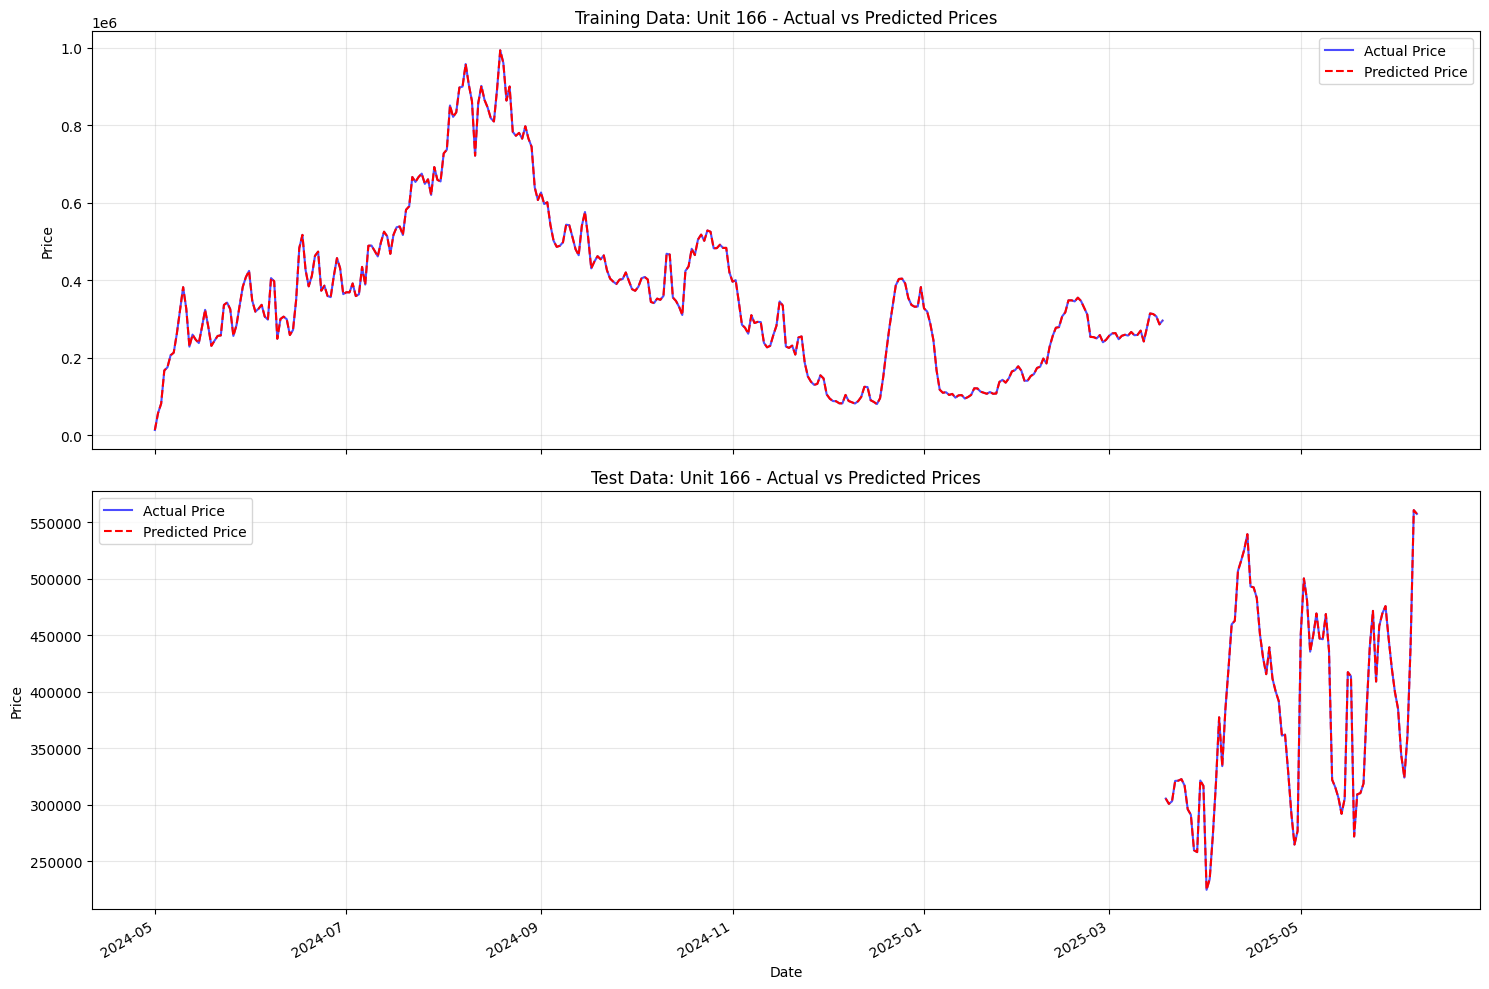

Plotting predictions on the full unit DataFrame...
Model expects features: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: total_price_166


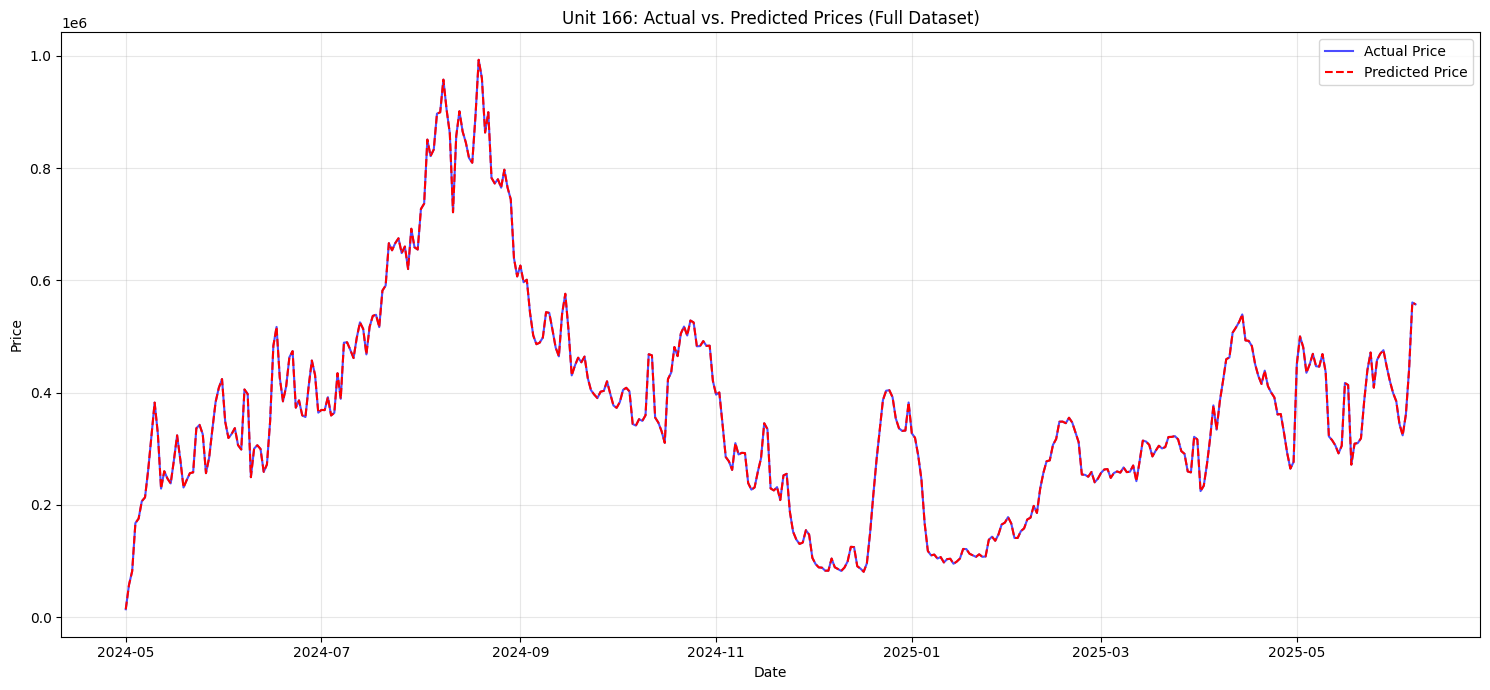


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---


In [17]:
model_results_166 = run_linear_regression_pipeline(
    df_unit = df_166_weather,
    unit_id = '166',
    test_size = 0.2,
    target_type = 'price',
    feature_columns = custom_features
)

--- Starting Linear Regression Pipeline for Unit 166 ---
Target type: taux (predicting occupancy rate)
Custom features specified: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']

[Step 1/3] Splitting data with test_size=0.2...
Using specified features: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Split complete. Test size: 0.20
Target column: taux_occupation_166
Features used: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Training set range: 2024-05-01 00:00:00 to 2025-03-18 00:00:00 (322 sample

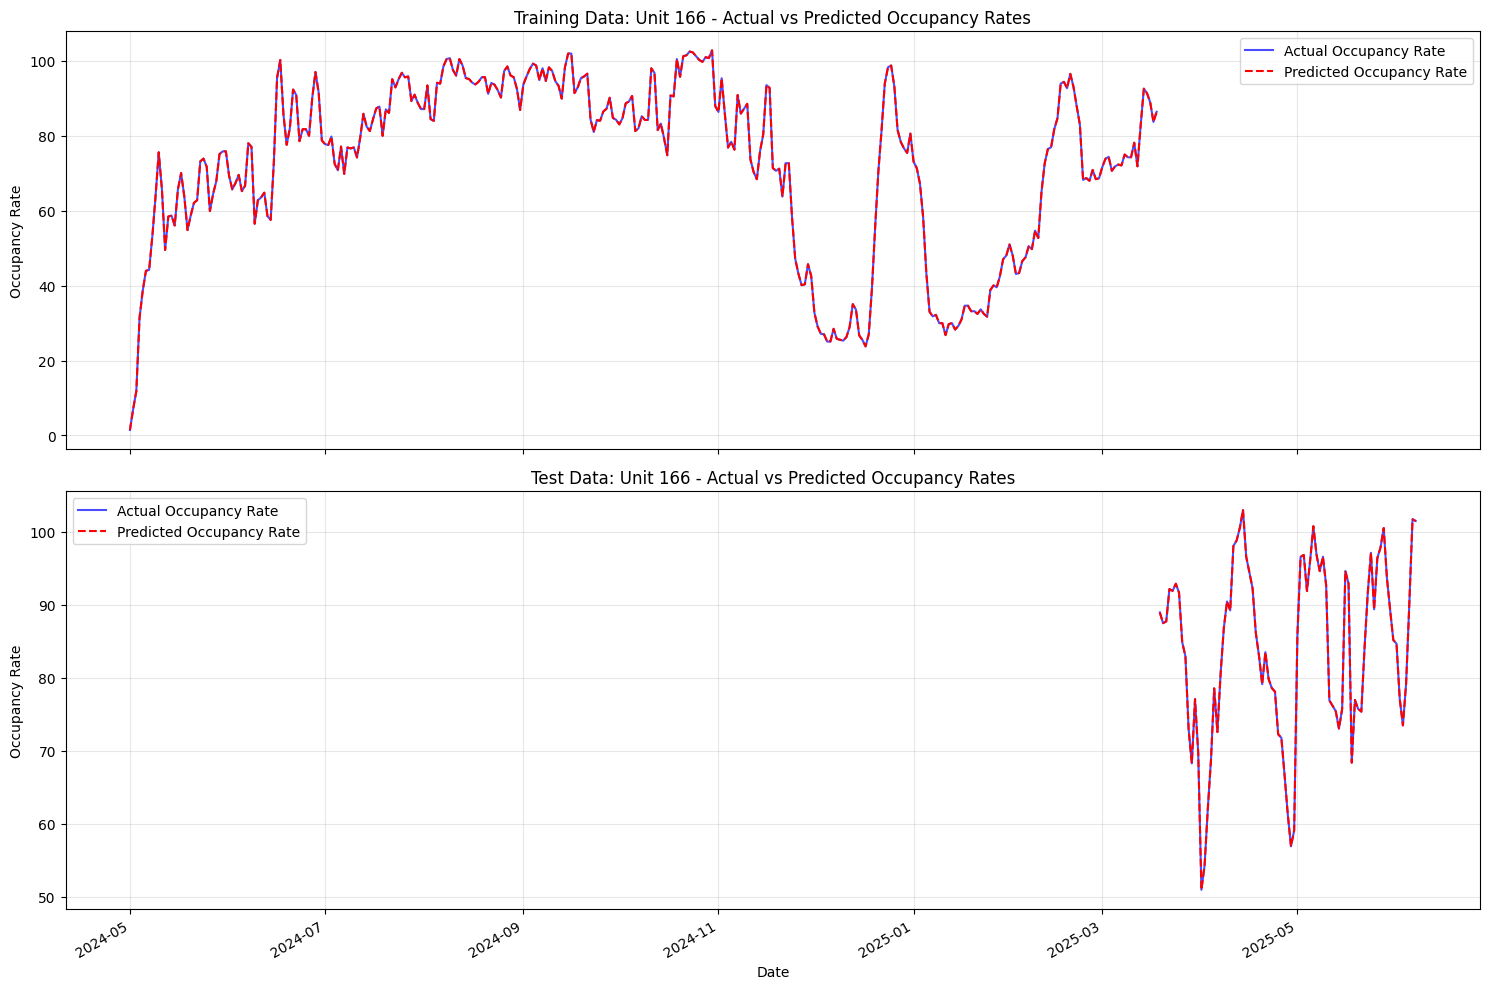

Plotting predictions on the full unit DataFrame...
Model expects features: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Columns used for prediction: ['dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 'total_price_166', 'taux_occupation_166', 'temperature_max', 'temperature_min', 'temperature_mean', 'precipitation', 'windspeed_max', 'temperature_range']
Target column: taux_occupation_166


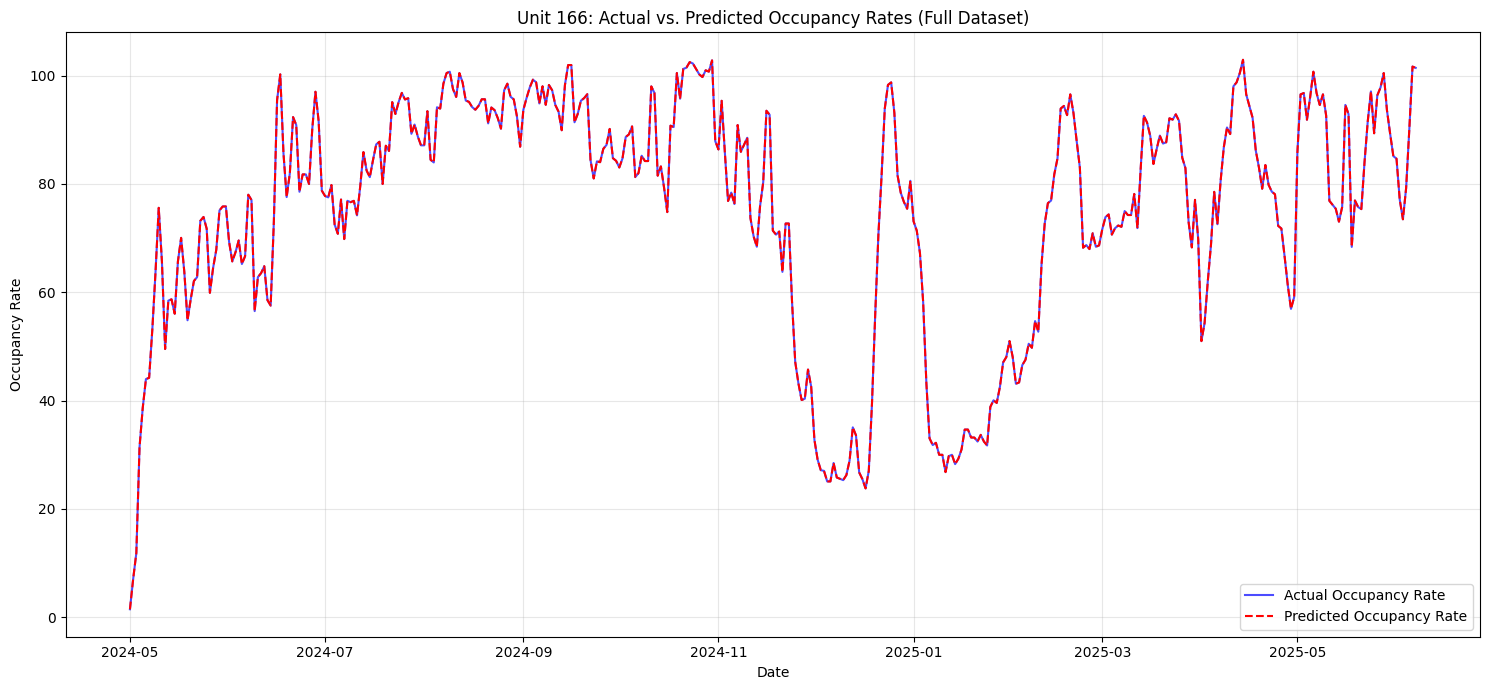


Pipeline finished for Unit 166.
--- End Linear Regression Pipeline ---


In [18]:
model_results_166 = run_linear_regression_pipeline(
    df_unit = df_166_weather,
    unit_id = '166',
    test_size = 0.2,
    target_type = 'taux',
    feature_columns = custom_features
)

In [ ]:
def get_weather_dataframe_for_city_single_date(date: str, city: str):
    """
    Fetches weather data for a specific city for a single date and returns it as a pandas DataFrame.
    
    Args:
        date (str): The date in "YYYY-MM-DD" format.
        city (str): The name of the city.
    """
    try:
        lat, lon = get_coordinates(city)
        
        if lat is None or lon is None:
            print(f"Could not find coordinates for city: {city}")
            return pd.DataFrame()
        
        print(f"Found coordinates for {city}: {lat:.4f}, {lon:.4f}")
        
        weather_data = fetch_weather_data(date, date, lat, lon)
        
        if not weather_data:
            print(f"No weather data retrieved for {city} on {date}")
            return pd.DataFrame()
        
        df = pd.DataFrame.from_dict(weather_data, orient='index')
        df.index = pd.to_datetime(df.index)
        df.index.name = 'date'
        
        df['temperature_range'] = df['temperature_max'] - df['temperature_min']
        
        numerical_cols = ['temperature_max', 'temperature_min', 'temperature_mean', 
                         'precipitation', 'windspeed_max', 'temperature_range']
        df[numerical_cols] = df[numerical_cols].round(3)
        
        df.fillna(0, inplace=True)
        
        print(f"Successfully created DataFrame for {city} on {date}")
        return df
        
    except Exception as e:
        print(f"Error creating weather DataFrame for city {city} on {date}: {e}")
        return pd.DataFrame()

In [23]:
df = get_weather_dataframe_for_city_single_date("2024-01-15", "Paris")

Found coordinates for Paris: 48.8589, 2.3200
Fetching historical data only
Coordinates 48.892791748046875°N 2.292020559310913°E
Elevation 38.0 m asl
Timezone NoneNone
Successfully fetched weather data for 1 dates
Successfully created DataFrame for Paris on 2024-01-15


In [29]:
df.loc['2024-01-15'].tolist()

[4.687, -3.914, 0.897, 0.3, 17.655, 8.6]

In [37]:
def predict_single_date_linear_model(model, target_date_str, unit_id, value_target, target_type='price', city=metaData['weatherInformation']['default_city']):
    """
    Predicts either price or occupancy rate for a single future date using a trained linear regression model,
    including weather features for the specified date and city.

    Args:
        model: The trained scikit-learn compatible linear regression model.
        target_date_str (str): The target date for prediction in 'YYYY-MM-DD' format.
        unit_id (str): The identifier for the unit (e.g., '166', '167').
        value_target (float): The value for the non-target feature (price or taux_occupation).
        target_type (str): Type of prediction ('price' or 'taux'). Defaults to 'price'.
        city (str): City name for weather data. Defaults to 'Paris'.
    """
    try:
        target_date = pd.to_datetime(target_date_str)
    except ValueError:
        print(f"Error: Invalid target_date_str format: {target_date_str}. Please use 'YYYY-MM-DD'.")
        return None

    if target_type.lower() == 'price':
        feature_name = f'taux_occupation_{unit_id}'
        target_name = f'total_price_{unit_id}'
    else:  # 'taux'
        feature_name = f'total_price_{unit_id}'
        target_name = f'taux_occupation_{unit_id}'

    # Base features (date-related)
    features = {
        'dayofweek': target_date.dayofweek,
        'month': target_date.month,
        'year': target_date.year,
        'dayofyear': target_date.dayofyear,
        'weekofyear': int(target_date.isocalendar()[1]),
        feature_name: value_target
    }

    # Get weather data for the specific date and city
    try:
        
        weather_df = get_weather_dataframe_for_city_single_date(target_date_str, city)
        
        if not weather_df.empty:
            # Extract weather features from the DataFrame
            weather_row = weather_df.iloc[0]  # Get the first (and only) row
            
            # Add weather features to the features dictionary
            features.update({
                'temperature_max': weather_row['temperature_max'],
                'temperature_min': weather_row['temperature_min'],
                'temperature_mean': weather_row['temperature_mean'],
                'precipitation': weather_row['precipitation'],
                'windspeed_max': weather_row['windspeed_max'],
                'temperature_range': weather_row['temperature_range']
            })
            
            print(f"Weather data successfully retrieved for {city} on {target_date_str}")
        else:
            print(f"Warning: No weather data available for {city} on {target_date_str}. Using default values.")
            # Use default weather values if no data is available
            features.update({
                'temperature_max': 0.0,
                'temperature_min': 0.0,
                'temperature_mean': 0.0,
                'precipitation': 0.0,
                'windspeed_max': 0.0,
                'temperature_range': 0.0
            })
            
    except Exception as e:
        print(f"Error retrieving weather data: {e}")
        print("Using default weather values.")
        # Use default weather values if there's an error
        features.update({
            'temperature_max': 0.0,
            'temperature_min': 0.0,
            'temperature_mean': 0.0,
            'precipitation': 0.0,
            'windspeed_max': 0.0,
            'temperature_range': 0.0
        })

    # Determine feature order from the model
    if hasattr(model, 'feature_names_in_'):
        feature_order = list(model.feature_names_in_)
    else:
        # Default feature order including weather features
        feature_order = [
            'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear', 
            feature_name,
            'temperature_max', 'temperature_min', 'temperature_mean', 
            'precipitation', 'windspeed_max', 'temperature_range'
        ]
        print(f"Warning: Model does not have 'feature_names_in_'. Using default feature order: {feature_order}")
    
    # Create DataFrame for prediction
    try:
        # Only include features that are in the model's expected feature order
        model_features = {col: features.get(col, 0.0) for col in feature_order}
        input_df = pd.DataFrame([model_features], columns=feature_order)
    except Exception as e:
        print(f"Error creating DataFrame for prediction: {e}")
        return None
        
    # Validate that all required features are present
    for col in feature_order:
        if col not in input_df.columns:
            print(f"Error: Missing expected feature '{col}' in the generated input.")
            return None
            
    print(f"\nPredicting {target_name} for Unit {unit_id} on {target_date_str} with features:")

    # Make prediction
    try:
        prediction = model.predict(input_df)
        return prediction[0]  
    except Exception as e:
        print(f"Error during prediction: {e}")
        
        if hasattr(model, 'feature_names_in_'):
            print(f"Model was trained with features: {model.feature_names_in_}")
        print(f"Input features provided: {input_df.columns.tolist()}")
        
        return None

In [44]:
prediction = predict_single_date_linear_model(
    model = model_results_166['model'],
    target_date_str = '2025-01-15',
    unit_id = '166',
    value_target = 200000,
    target_type = 'taux'
)

Found coordinates for Marrakech: 31.6258, -7.9892
Fetching historical data only
Coordinates 31.59929656982422°N -7.97607421875°E
Elevation 468.0 m asl
Timezone NoneNone
Successfully fetched weather data for 1 dates
Successfully created DataFrame for Marrakech on 2025-01-15
Weather data successfully retrieved for Marrakech on 2025-01-15

Predicting taux_occupation_166 for Unit 166 on 2025-01-15 with features:


In [45]:
prediction

-9.145072909020028e-13

In [46]:
test = find_max_price_for_single_date_linear_model(
    target_date_str= '2024-06-19',
    unit_id = '166',
    target_type = 'taux',
    max_value= 800000,
    min_value= 100000,
    step= 1000,
)

Loading model for target='taux', unit='166'...
Model name: linear_regression_model_166
Model successfully loaded from ../TrainedModels/UnitsBasedModels/PredictTaux/LinearRegression\linear_regression_model_166.pkl
Model loaded successfully.

Searching for optimal price for unit 166 on 2024-06-19
Range: 100000.00-800000.00, step: 1000
Target: maximize predicted taux_occupation


Testing price values:   9%|▉         | 64/701 [00:00<00:01, 319.98it/s]


Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         100000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         101000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         102000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         103000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171

Testing price values:  14%|█▍        | 99/701 [00:00<00:01, 330.80it/s]


Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         164000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         165000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         166000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         167000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171

...


Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         674000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         675000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         676000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         677000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171

Testing price values:  91%|█████████▏| 640/701 [00:02<00:00, 276.59it/s]


Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         740000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         741000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         742000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         743000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171

Testing price values: 100%|██████████| 701/701 [00:02<00:00, 306.64it/s]


Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         772000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         773000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         774000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171          25         775000.0

Predicting taux_occupation_166 for Unit 166 on 2024-06-19 with features:
   dayofweek  month  year  dayofyear  weekofyear  total_price_166
0          2      6  2024        171

In [47]:
test

(800000.0, 35.686168473315774)